#Titanic Data Analysis & Modeling

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Part 1: EDA

In [ ]:
#import dataset
data=pd.read_csv('train.csv')

In [ ]:
#check first 5 rows of dataset
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#checking info of dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


###Q#1: How many rows and columns does the dataset contain?

Rows=891 \\
Columns=12

###Q#2: What data types are present? Are there any missing values?

Dataset has integer datatype, float datatype and string datatype. \\
Yes, there are missing values in the data set.

In [ ]:
#checking missing values of dataset
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age Column have 177 missing values. \\
Cabin Column have 687 missing values. \\
Embarked Column have 2 missing values.


### Q#3: What is the overall survival rate?

In [ ]:
survivals=data['Survived'].value_counts()
survived=survivals[1]
non_survived=survivals[0]
total=len(data)

In [ ]:
#rate of survived passengers
rate1=(survived/total)*100
rate1

38.38383838383838

In [ ]:
#rate of non survived passengers
rate2=(non_survived/total)*100
rate2

61.61616161616161

Rate of survived passengers is 38.38% \\
Rate of non survived passengers is 61.62%

### Q#4: What are the distributions of age, fare, and passenger class?

In [ ]:
#age distribution
print(data['Age'].describe())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


Average age of passengers is 29.7 Years \\
Minimum age of passenger is 0.42 Years \\
Maximum age of passenger is 80 Years \\
\
25% passengers are less than 20 years \\
50% passengers are less than 28 years \\
and 75% passengers are less than 38 years

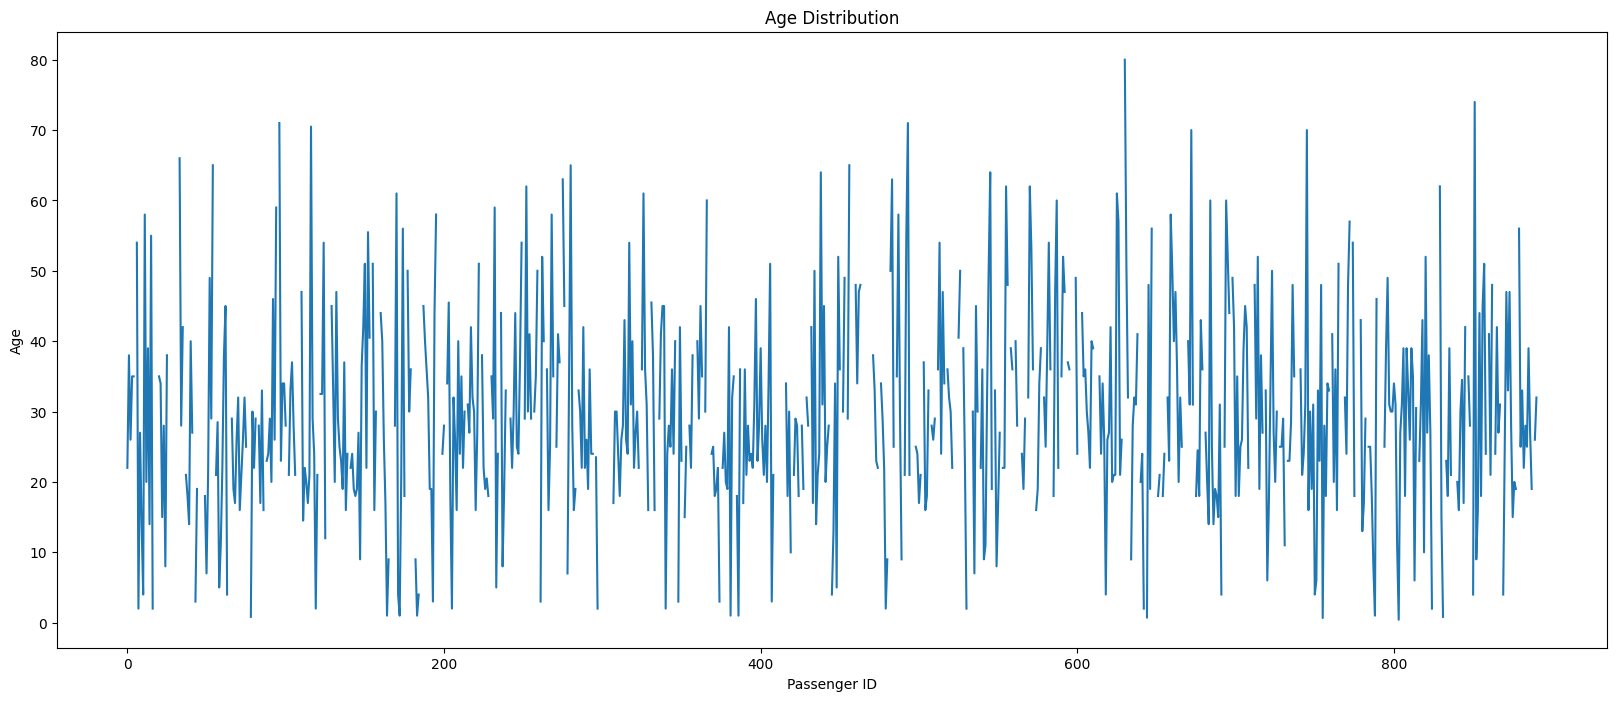

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(data['Age'])
plt.title('Age Distribution')
plt.xlabel('Passenger ID')
plt.ylabel('Age')
plt.show()

In [ ]:
#fare distribution
print(data['Fare'].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


Average fare is 32.2 \\
Minimum fare is 0 \\
Maximum fare is 512 \\
\
About 25% passengers paid less than 8 \\
About 50% passengers paid less than 14 \\
About 75% passengers paid less than 512


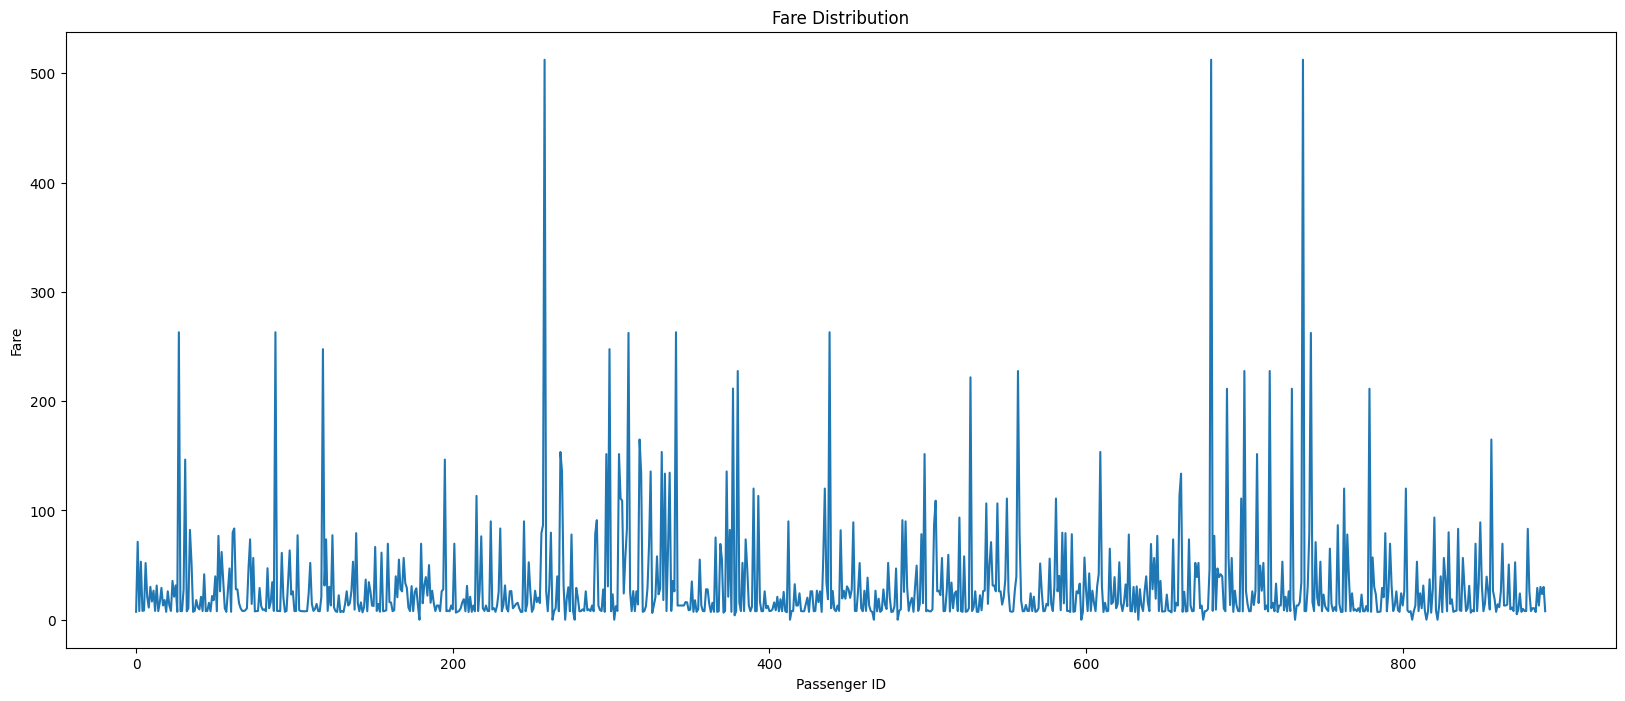

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(data['Fare'])
plt.title('Fare Distribution')
plt.xlabel('Passenger ID')
plt.ylabel('Fare')
plt.show()

In [ ]:
#passenger class distribution
print(data['Pclass'].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [ ]:
c3=data['Pclass'].value_counts()[3]
c2=data['Pclass'].value_counts()[2]
c1=data['Pclass'].value_counts()[1]
T=len(data['Pclass'])

In [ ]:
PC3=(c3/T)*100
PC2=(c2/T)*100
PC1=(c1/T)*100
print('Class 3 passengers:', PC3)
print('Class 2 passengers:',PC2)
print('Class 1 passengers:',PC1)

Class 3 passengers: 55.106621773288445
Class 2 passengers: 20.65095398428732
Class 1 passengers: 24.242424242424242


55% passengers are of class 3 \\
21% passengers are of class 2 \\
24% passengers are of class 1 \\

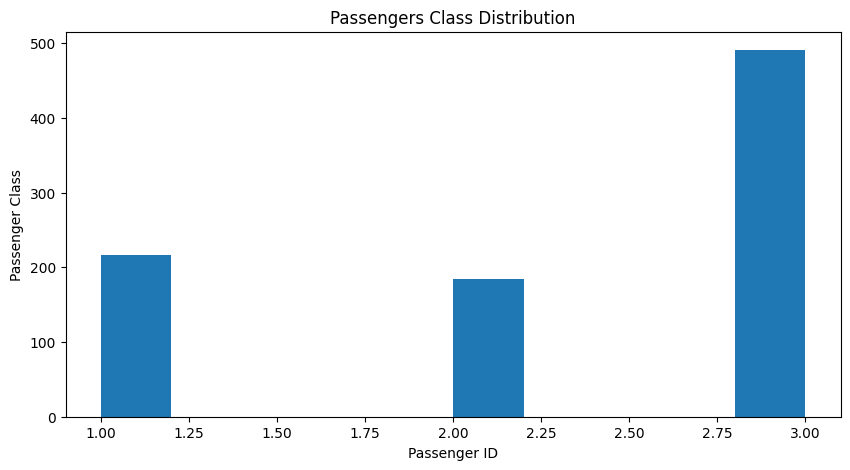

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(data['Pclass'])
plt.title('Passengers Class Distribution')
plt.xlabel('Passenger ID')
plt.ylabel('Passenger Class')
plt.show()

### Q#5: How does survival rate vary with:

In [ ]:
#Gender
t_males = int(data[data['Sex'] == 'male']['Survived'].count())            #total males
t_females = int(data[data['Sex'] == 'female']['Survived'].count())        #total females

In [ ]:
s_male = int(data[(data['Sex'] == 'male') & (data['Survived'] == 1)].count()['Survived'])       #survived males
s_female = int(data[(data['Sex'] == 'female') & (data['Survived'] == 1)].count()['Survived'])    #survived females

In [ ]:
Male_Survival_Rate = (s_male / t_males) * 100
Female_Survival_Rate = (s_female / t_females) * 100

In [ ]:
print(f'Survived male are {Male_Survival_Rate:.0f}%')
print(f'Survived female are {Female_Survival_Rate:.0f}%')

Survived male are 19%
Survived female are 74%


19% of males are survived and 74% of females are survived

In [ ]:
#Age
t_childern=(data['Age']<18).sum()   #total childern
t_adults=(data['Age']>=18).sum()     #total adults

In [ ]:
s_childern = int(data[(data['Age'] < 18) & (data['Survived'] == 1)].count()['Survived'])    #survived childern
s_adults = int(data[(data['Age'] >= 18) & (data['Survived'] == 1)].count()['Survived'])     #survived adults

In [ ]:
Child_Survival_Rate = (s_childern / t_childern) * 100
Adult_Survival_Rate = (s_adults / t_adults) * 100

In [ ]:
print(f'Survived childern are {Child_Survival_Rate:.0f}%')
print(f'Survived adults are {Adult_Survival_Rate:.0f}%')

Survived childern are 54%
Survived adults are 38%


54% of childern are survived and 38% of adults are survived

In [ ]:
#Passenger Class
t_C3=(data['Pclass']==3).sum()      #total passengers of class 3
t_C2=(data['Pclass']==2).sum()      #total passengers of class 2
t_C1=(data['Pclass']==1).sum()      #total passengers of class 1

In [ ]:
s_C3 = int(data[(data['Pclass'] ==3) & (data['Survived'] == 1)].count()['Survived'])    #survived passengers of class 3
s_C2 = int(data[(data['Pclass'] ==2) & (data['Survived'] == 1)].count()['Survived'])    #survived passengers of class 2
s_C1 = int(data[(data['Pclass'] ==1) & (data['Survived'] == 1)].count()['Survived'])    #survived passengers of class 1

In [ ]:
C3_Survival_Rate = (s_C3 / t_C3)*100
C2_Survival_Rate = (s_C2 / t_C2)*100
C1_Survival_Rate = (s_C1 / t_C1)*100

In [ ]:
print(f'Survivals in passenger class 3 are {C3_Survival_Rate:.0f}%')
print(f'Survivals in passenger class 2 are {C2_Survival_Rate:.0f}%')
print(f'Survivals in passenger class 1 are {C1_Survival_Rate:.0f}%')

Survivals in passenger class 3 are 24%
Survivals in passenger class 2 are 47%
Survivals in passenger class 1 are 63%


Survivals from passenger class 1 is highest while survivals from passenger class 3 is lowest

In [ ]:
#Port of embarkation
unique_groups = data['Embarked'].unique()
print("Group types:", unique_groups)

Group types: ['S' 'C' 'Q' nan]


In [ ]:
group_counts = data['Embarked'].value_counts()
print(group_counts)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [ ]:
t_emb_S=(data['Embarked']=='S').sum()     #total passengers embarked at port S
t_emb_C=(data['Embarked']=='C').sum()     #total passengers embarked at port C
t_emb_Q=(data['Embarked']=='Q').sum()     #total passengers embarked at port Q

In [ ]:
s_emb_S = int(data[(data['Embarked'] =='S') & (data['Survived'] == 1)].count()['Survived'])     #survived passengers embarked at port S
s_emb_C = int(data[(data['Embarked'] =='C') & (data['Survived'] == 1)].count()['Survived'])     #survived passengers embarked at port C
s_emb_Q = int(data[(data['Embarked'] =='Q') & (data['Survived'] == 1)].count()['Survived'])     #survived passengers embarked at port Q

In [ ]:
emb_S_Survival_Rate = (s_emb_S / t_emb_S)*100
emb_C_Survival_Rate = (s_emb_C / t_emb_C)*100
emb_Q_Survival_Rate = (s_emb_Q / t_emb_Q)*100

In [ ]:
print(f'Survivals of passengers from S Port of embarkation are {emb_S_Survival_Rate:.0f}%')
print(f'Survivals of passengers from C Port of embarkation are {emb_C_Survival_Rate:.0f}%')
print(f'Survivals of passengers from Q Port of embarkation are {emb_Q_Survival_Rate:.0f}%')

Survivals of passengers from S Port of embarkation are 34%
Survivals of passengers from C Port of embarkation are 55%
Survivals of passengers from Q Port of embarkation are 39%


Survivals of passengers from C Port of embarkation is highest and Survivals of passengers from S Port of embarkation are lowest

In [ ]:
#family members
data['Family_Members'] = data['SibSp'] + data['Parch']

In [ ]:
group_counts = data['Family_Members'].value_counts()
print(group_counts)

Family_Members
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64


In [ ]:
t_FM_0=(data['Family_Members']==0).sum()        #total passengers with 0 family members
t_FM_1=(data['Family_Members']==1).sum()        #total passengers with 1 family members
t_FM_2=(data['Family_Members']==2).sum()        #total passengers with 2 family members
t_FM_3=(data['Family_Members']==3).sum()        #total passengers with 3 family members
t_FM_4=(data['Family_Members']==4).sum()        #total passengers with 4 family members
t_FM_5=(data['Family_Members']==5).sum()        #total passengers with 5 family members
t_FM_6=(data['Family_Members']==6).sum()        #total passengers with 6 family members
t_FM_7=(data['Family_Members']==7).sum()        #total passengers with 7 family members
t_FM_10=(data['Family_Members']==10).sum()      #total passengers with 10 family members

In [ ]:
s_FM_0 = int(data[(data['Family_Members'] ==0) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 0 family members
s_FM_1 = int(data[(data['Family_Members'] ==1) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 1 family members
s_FM_2 = int(data[(data['Family_Members'] ==2) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 2 family members
s_FM_3 = int(data[(data['Family_Members'] ==3) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 3 family members
s_FM_4 = int(data[(data['Family_Members'] ==4) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 4 family members
s_FM_5 = int(data[(data['Family_Members'] ==5) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 5 family members
s_FM_6 = int(data[(data['Family_Members'] ==6) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 6 family members
s_FM_7 = int(data[(data['Family_Members'] ==7) & (data['Survived'] == 1)].count()['Survived'])      #survived passengers with 7 family members
s_FM_10 = int(data[(data['Family_Members'] ==10) & (data['Survived'] == 1)].count()['Survived'])    #survived passengers with 10 family members

In [ ]:
FM_0_Survival_Rate = (s_FM_0 / t_FM_0)*100
FM_1_Survival_Rate = (s_FM_1 / t_FM_1)*100
FM_2_Survival_Rate = (s_FM_2 / t_FM_2)*100
FM_3_Survival_Rate = (s_FM_3 / t_FM_3)*100
FM_4_Survival_Rate = (s_FM_4 / t_FM_4)*100
FM_5_Survival_Rate = (s_FM_5 / t_FM_5)*100
FM_6_Survival_Rate = (s_FM_6 / t_FM_6)*100
FM_7_Survival_Rate = (s_FM_7 / t_FM_7)*100
FM_10_Survival_Rate = (s_FM_10 / t_FM_10)*100

In [ ]:
print(f'Survival of passengers with 0 family members are {FM_0_Survival_Rate:.0f}%')
print(f'Survival of passengers with 1 family members are {FM_1_Survival_Rate:.0f}%')
print(f'Survival of passengers with 2 family members are {FM_2_Survival_Rate:.0f}%')
print(f'Survival of passengers with 3 family members are {FM_3_Survival_Rate:.0f}%')
print(f'Survival of passengers with 4 family members are {FM_4_Survival_Rate:.0f}%')
print(f'Survival of passengers with 5 family members are {FM_5_Survival_Rate:.0f}%')
print(f'Survival of passengers with 6 family members are {FM_6_Survival_Rate:.0f}%')
print(f'Survival of passengers with 7 family members are {FM_7_Survival_Rate:.0f}%')
print(f'Survival of passengers with 10 family members are {FM_10_Survival_Rate:.0f}%')

Survival of passengers with 0 family members are 30%
Survival of passengers with 1 family members are 55%
Survival of passengers with 2 family members are 58%
Survival of passengers with 3 family members are 72%
Survival of passengers with 4 family members are 20%
Survival of passengers with 5 family members are 14%
Survival of passengers with 6 family members are 33%
Survival of passengers with 7 family members are 0%
Survival of passengers with 10 family members are 0%


Survival of passengers with more family members is less as compared to passengers with less family members

### Q#6: Are there any noticeable patterns or trends?

**Gender:** Females have higher survival rate than males.

**Age:** More Children were survived than adults.

**Passenger Class:** Class 1 passengers had the high survival rates and Class 3 had the lowest.

**Embarkation Port:** Passengers from Port C had the highest survival rate.

**Family Size:** Small families (1–3 members) had better chance of survival than those with no family or very large families.

### Q#7: Which columns have missing values, and how do you handle them?

In [ ]:
#Check null values
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age, Cabin and Embarked columns have missing values \\
\
In age column i'll try to fill it with mean of age because it gives a central estimate of age. \\
In embarked column i'll try to fill it with mode of embarked because there were very few missing values, and the mode represents the most common port of embarkation. \\
In cabin column i'll try to fill it with mode of cabin for simplicity

In [ ]:
data.fillna({'Age': data['Age'].mean()}, inplace=True)
data.fillna({'Cabin': data['Cabin'].mode()[0]}, inplace=True)
data.fillna({'Embarked': data['Embarked'].mode()[0]}, inplace=True)

In [ ]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Q#8: What features are most correlated with survival?

to check correlation, convert categorical data into numerical data



In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Members
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


In [ ]:
ohe=OneHotEncoder()
columns_to_encode = ['Sex', 'Embarked']
ohe_array = ohe.fit_transform(data[columns_to_encode])
ohe_array=ohe_array.toarray()
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(columns_to_encode))
ohe_df.index = data.index
DF = pd.concat([data.drop(columns_to_encode, axis=1), ohe_df], axis=1)

In [ ]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PassengerId     891 non-null    int64  
 1   Survived        891 non-null    int64  
 2   Pclass          891 non-null    int64  
 3   Name            891 non-null    object 
 4   Age             891 non-null    float64
 5   SibSp           891 non-null    int64  
 6   Parch           891 non-null    int64  
 7   Ticket          891 non-null    object 
 8   Fare            891 non-null    float64
 9   Cabin           891 non-null    object 
 10  Family_Members  891 non-null    int64  
 11  Sex_female      891 non-null    float64
 12  Sex_male        891 non-null    float64
 13  Embarked_C      891 non-null    float64
 14  Embarked_Q      891 non-null    float64
 15  Embarked_S      891 non-null    float64
dtypes: float64(7), int64(6), object(3)
memory usage: 111.5+ KB


In [ ]:
#drop useless columns
df=DF.drop(['PassengerId','Name','Ticket','Cabin','SibSp','Parch'],axis=1)

In [ ]:
df.head(2)

,Survived,Pclass,Age,Fare,Family_Members,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,7.2500,1,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,71.2833,1,1.0,0.0,1.0,0.0,0.0


In [ ]:
correlation = df.corr(numeric_only=True)
print(correlation['Survived'].sort_values(ascending=False))   #correlation of features with survived passengers

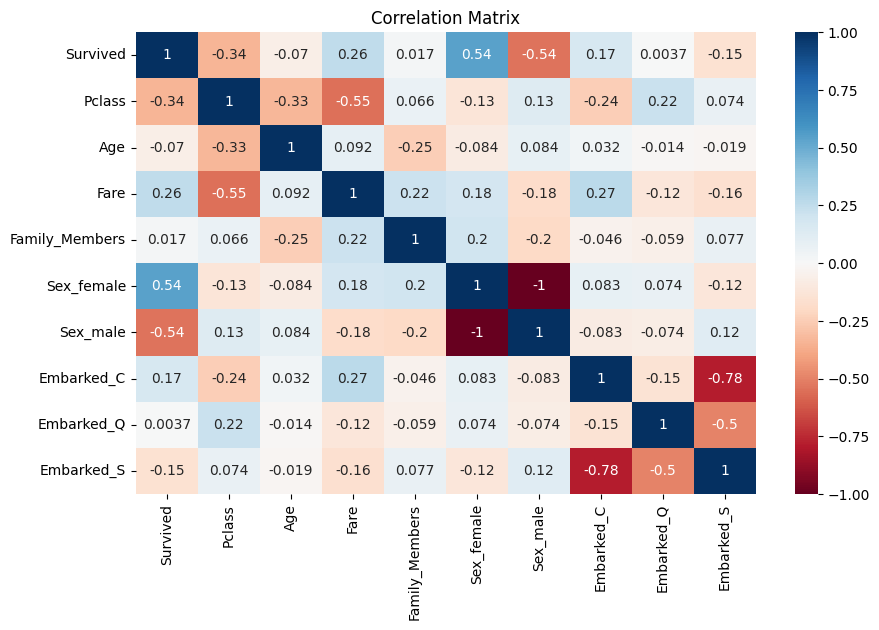

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu')
plt.title("Correlation Matrix")
plt.show()

+1: Strong positive correlation \\

0: No correlation \\

-1: Strong negative correlation



dark blue color means they are strongly related and dark red means not related.

## Part 2: Predictive Modeling (Classification)

In [ ]:
df_=df.drop(['Embarked_C','Sex_female'],axis=1)

### Q#9: How did you handle categorical variables (Sex, Embarked)?

I used onehotencoder to handle categorical data

### Q#9: Did you create any new features (e.g., age bins, family size)? If so, explain your rationale.

Yes, i created a new feature named Family_Members by combining SibSp and Parch

Because Combining SibSp and Parch into FamilyMembers gives an idea of the total family size.

### Q#10: Train a Logistic Regression model and one additional model of your choice (e.g., Decision Tree, Random Forest, or Gradient Boosting).

In [ ]:
#separate features and labels
X=df_.drop('Survived', axis=1)
Y=df_['Survived']

In [ ]:
from sklearn.model_selection import cross_val_score, KFold , cross_val_predict
kfold = KFold(n_splits=10)

### Q#11: Show how you split the data into training and testing sets.

I used cross validation instead of train test split for more reliable estimates of model performance because CV evaluates it on multiple data folds, reducing variability and overfitting risks."

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_Scaled=scaler.fit_transform(X)

In [ ]:
#logistic regression
from sklearn.linear_model import LogisticRegression

In [ ]:
model1=LogisticRegression()

In [ ]:
scores1 = cross_val_score(model1, X_Scaled, Y, cv=kfold, scoring="accuracy")
print(f'Accuracy for logistic regression is {scores1.mean() *100:.2f}%')

Accuracy for logistic regression is 80.14%


In [ ]:
y_pred1= cross_val_predict(model1, X_Scaled, Y, cv=kfold)

In [ ]:
 #random forest classifier
 from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
model2=GradientBoostingClassifier()

In [ ]:
scores2 = cross_val_score(model2, X_Scaled, Y, cv=kfold, scoring="accuracy")
print(f'Accuracy for Gradient Boosting is {scores2.mean() *100:.2f}%')

Accuracy for Gradient Boosting is 82.61%


In [ ]:
y_pred2= cross_val_predict(model2, X_Scaled, Y, cv=kfold)

### Q#12: Report accuracy, precision, recall, and F1-score for each model.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
Report1 = classification_report(Y, y_pred1)
print(Report1)

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       549
           1       0.76      0.70      0.73       342

    accuracy                           0.80       891
   macro avg       0.79      0.78      0.79       891
weighted avg       0.80      0.80      0.80       891



In [ ]:
Report2 = classification_report(Y, y_pred2)
print(Report2)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       549
           1       0.82      0.70      0.75       342

    accuracy                           0.83       891
   macro avg       0.83      0.80      0.81       891
weighted avg       0.83      0.83      0.82       891



### Q#13: Display the confusion matrix and ROC-AUC curve (if applicable).

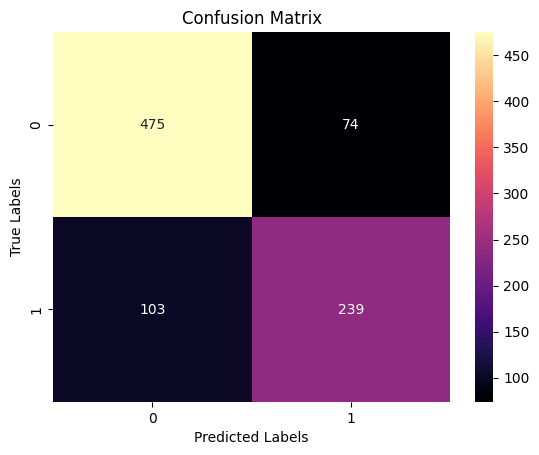

In [ ]:
cm1 = confusion_matrix(Y,y_pred1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='magma')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

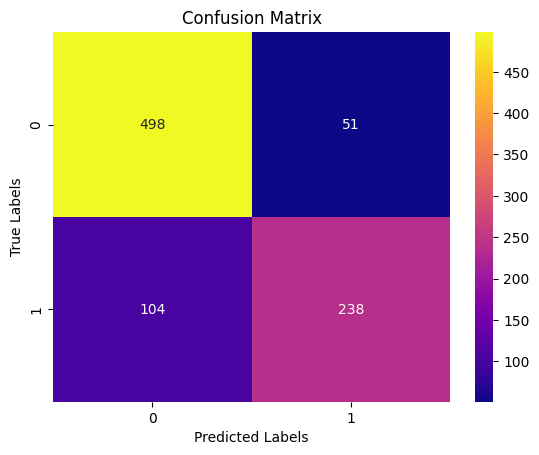

In [ ]:
 cm2 = confusion_matrix(Y,y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='plasma')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### Q#14: Which model performs better and why?

I trained two models Logistic Regression and Gradient Boosting Classifier. \\
The Gradient Boosting Classifier performs better than the Logistic Regression model because it achieved a higher score of 82% compared to 80% from Logistic Regression. Gradient Boosting performs better because it’s like a team of decision trees working together, each one learning from the mistakes of the previous one. This helps it catch more complex patterns in the data, while Logistic Regression is simpler and works best when the data has clear, straight-line relationships.

### Q#15: What are the most important features influencing survival predictions in your best model?

Sex – Gender had the strongest impact, with females having a higher survival rate.

Pclass – The passenger class (1, 2, 3) influenced survival, with class 1 passengers more likely to survive.

Age – Young passengers had higher survival chances.

Fare – Higher fare amounts were associated with higher survival.

Embarked – The port of embarkation also had a smaller influence on survival outcomes.

### Q#16: Provide a brief explanation of how your model’s decisions can be interpreted?

Logistic Regression makes predictions using a simple formula. Each feature has a weight that shows how much it affects the result, so it’s easy to understand.

Gradient Boosting builds many small trees, each learning from the last one’s mistakes. It finds deeper patterns and usually gives better results. We can see which features mattered most by checking their importance scores.